In [1]:
import numpy as np
import matplotlib.pyplot as plt

#### GAN Data Plot

Plotting all of the data from the GAN.

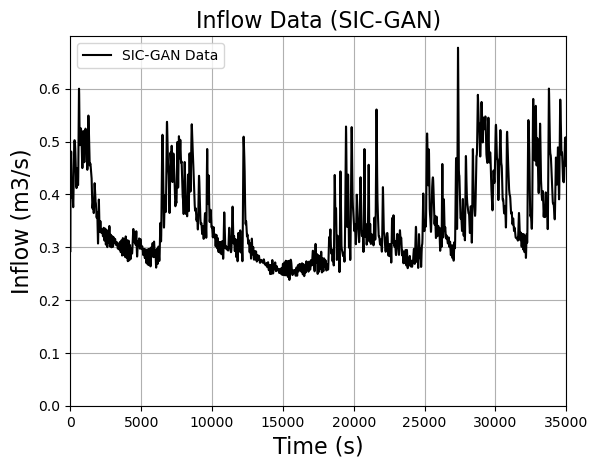

In [2]:
#Inflow data
inflowData = np.loadtxt("ganData.txt", dtype = float).tolist()

xData = [c for c in range(len(inflowData))]
plt.plot(xData, inflowData, color = "black", label = "SIC-GAN Data")
plt.legend()
plt.xlim(0, len(inflowData))
plt.ylim(0,)
plt.title("Inflow Data (SIC-GAN)", fontsize = 16)
plt.ylabel("Inflow (m3/s)", fontsize = 16)
plt.xlabel("Time (s)", fontsize = 16)
plt.grid(True)
plt.show()

#### Splitting to training data and validation data x3.

70% of the data is in the training data set, 10% for validationLow, 10% for validationHigh, 10% for validationNormal

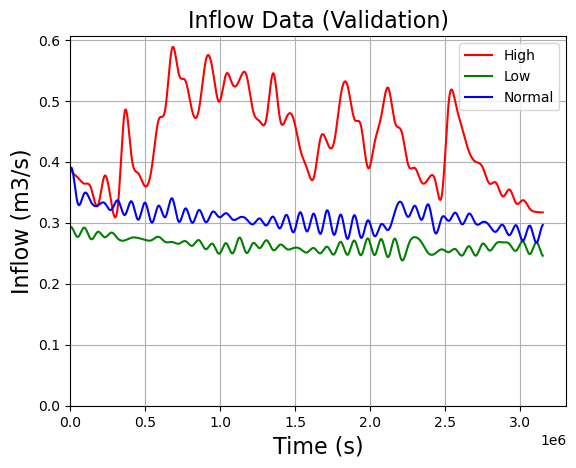

In [3]:
cutHigh = (28000, 31500)
cutLow = (13000, 16500)
cutNormal = (2000, 5500)

validationHigh = inflowData[cutHigh[0]:cutHigh[1]]
validationLow = inflowData[cutLow[0]:cutLow[1]]
validationNormal = inflowData[cutNormal[0]:cutNormal[1]]

trainingData = (
    inflowData[:cutHigh[0]] +
    inflowData[cutHigh[1]:cutLow[0]] +
    inflowData[cutLow[1]:cutNormal[0]] +
    inflowData[cutNormal[1]:]
)
xData = [15 * 60 * c for c in range(3500)]
plt.plot(xData, validationHigh, color = "red", label = "High")
plt.plot(xData, validationLow, color = "green", label = "Low")
plt.plot(xData, validationNormal, color = "blue", label = "Normal")
plt.legend()
plt.xlim(0,)
plt.title("Inflow Data (Validation)", fontsize = 16)
plt.ylim(0,)
plt.ylabel("Inflow (m3/s)", fontsize = 16)
plt.xlabel("Time (s)", fontsize = 16)
plt.grid(True)
plt.show()

np.savetxt("trainingData.txt", trainingData)
np.savetxt("validationHigh.txt", validationHigh)
np.savetxt("validationLow.txt", validationLow)
np.savetxt("validationNormal.txt", validationNormal)